# Tier 2 Project Parts

Space Elevator Phase 1 & 2 production planning.

All quantities in **items/min**. Blueprints from `blueprints.py`, game data from `satisfactory.py`.

In [1]:
import os, shutil, subprocess

# Ensure graphviz dot binary is on PATH
if not shutil.which("dot"):
    result = subprocess.run(
        ["nix-build", "<nixpkgs>", "-A", "graphviz", "--no-out-link"],
        capture_output=True, text=True,
    )
    if result.returncode == 0 and result.stdout.strip():
        gv_bin = result.stdout.strip() + "/bin"
        os.environ["PATH"] = gv_bin + ":" + os.environ["PATH"]

from satisfactory import ITEMS, recipe_for
from blueprints import BLUEPRINTS, optimize_from_supply, PlanNode
import pandas as pd
import graphviz
from IPython.display import SVG, display
print('dot binary:', __import__('shutil').which('dot'))

dot binary: /nix/store/wg7nw3rri4z34fanql4dc2y640qaxwnz-graphviz-12.2.1/bin/dot


---
## Smart Plating

**Supply:** 270 iron-ingots/min (1 line)  
**Target:** maximise smart-plating output using blueprints only

In [2]:
SUPPLY_ITEM = 'iron-ingot'
SUPPLY_RATE = 270.0
TARGET_ITEM = 'smart-plating'

plan = optimize_from_supply(SUPPLY_ITEM, SUPPLY_RATE, TARGET_ITEM)
print(f'Max output: {plan.rate:.2f} {ITEMS[TARGET_ITEM].name}/min')
print(f'From:       {SUPPLY_RATE:.0f} {ITEMS[SUPPLY_ITEM].name}/min')

Max output: 11.61 Smart Plating/min
From:       270 Iron Ingot/min


### Blueprint placement plan

**Set output** = what to type into each copy's output rate in-game.  
Clock % is shown for reference only — it's derived from the output setting.

In [3]:
rows = []
for step in plan.blueprint_steps():
    product_name = ITEMS[step.item_key].name
    # Per-copy output = what you type into the machine UI for each placed copy
    per_copy_out = step.rate / step.copies
    per_copy_in  = {k: v / step.copies for k, v in step.effective_inputs.items()}
    rows.append({
        'Product':        product_name,
        'Copies to place': step.copies,
        'Set each to (output)': f'{per_copy_out:.2f}/min {product_name}',
        'Clock %':        f'{step.clock_pct:.1f}%',
        'Inputs per copy': '  +  '.join(f'{v:.1f}/min {ITEMS[k].name}' for k, v in per_copy_in.items()),
    })

df = pd.DataFrame(rows)
df.index.name = '#'
df

,Product,Copies to place,Set each to (output),Clock %,Inputs per copy
#,,,,,
0,Smart Plating,2,5.81/min Smart Plating,96.8%,5.8/min Reinforced Iron Plate + 5.8/min Rotor
1,Reinforced Iron Plate,1,11.61/min Reinforced Iron Plate,77.4%,69.7/min Iron Plate + 139.4/min Screw
2,Iron Plate,1,69.68/min Iron Plate,87.1%,104.5/min Iron Ingot
3,Screw,1,139.35/min Screw,87.1%,34.8/min Iron Ingot
4,Rotor,1,11.61/min Rotor,96.8%,58.1/min Iron Rod + 290.3/min Screw
5,Iron Rod,1,58.06/min Iron Rod,96.8%,58.1/min Iron Ingot
6,Screw,2,145.16/min Screw,90.7%,36.3/min Iron Ingot


### Production chain graph

Flow reads top → bottom (supply at top, final product at bottom).  
Edge labels show item + rate. Edge thickness scales with flow volume.

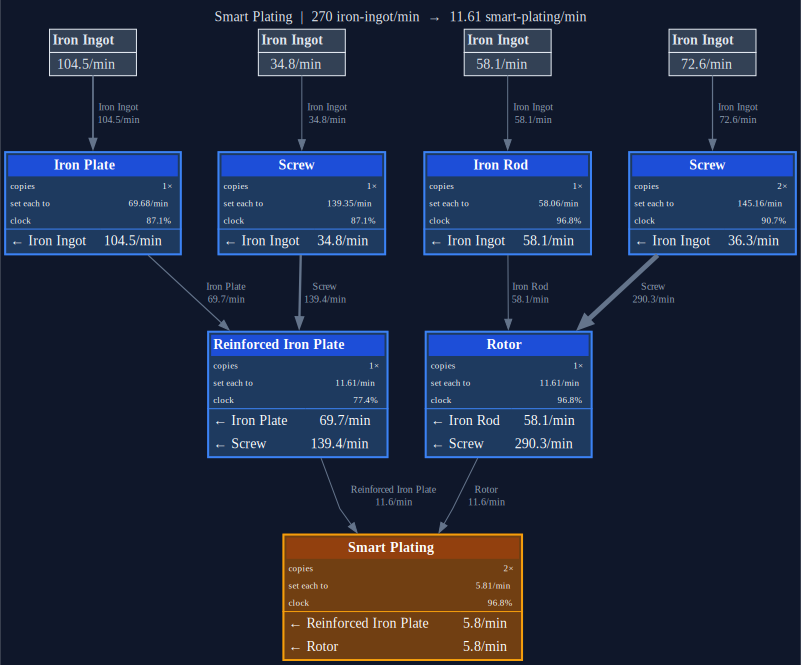

In [4]:
# Colour palette
C = {
    'supply_bg':   '#334155',  # slate — raw supply nodes
    'supply_fg':   '#e2e8f0',
    'bp_bg':       '#1e3a5f',  # dark blue — intermediate blueprints
    'bp_border':   '#3b82f6',
    'bp_fg':       '#ffffff',
    'bp_hd':       '#1d4ed8',  # header row of intermediate card
    'final_bg':    '#713f12',  # amber — final product
    'final_border':'#f59e0b',
    'final_hd':    '#92400e',
    'final_fg':    '#ffffff',
    'edge':        '#64748b',
    'edge_label':  '#94a3b8',
    'graph_bg':    '#0f172a',
}

def _esc(s):
    """Escape special HTML chars for graphviz labels."""
    return str(s).replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')

def _supply_label(item_key, rate):
    name = _esc(ITEMS[item_key].name)
    return (f'<<TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0" '
            f'BGCOLOR="{C["supply_bg"]}" COLOR="{C["supply_fg"]}">'
            f'<TR><TD><FONT COLOR="{C["supply_fg"]}"><B>{name}</B></FONT></TD></TR>'
            f'<TR><TD><FONT COLOR="{C["supply_fg"]}">{rate:.1f}/min</FONT></TD></TR>'
            f'</TABLE>>')

def _bp_label(node, is_final=False):
    name = _esc(ITEMS[node.item_key].name)
    bg    = C['final_bg']    if is_final else C['bp_bg']
    hd    = C['final_hd']    if is_final else C['bp_hd']
    bdr   = C['final_border']if is_final else C['bp_border']
    fg    = C['final_fg']

    per_copy = node.rate / node.copies
    in_rows = ''.join(
        f'<TR><TD ALIGN="LEFT"><FONT COLOR="{fg}">← {_esc(ITEMS[k].name)}</FONT></TD>'
        f'<TD ALIGN="RIGHT"><FONT COLOR="{fg}">{v/node.copies:.1f}/min</FONT></TD></TR>'
        for k, v in node.effective_inputs.items()
    )

    return (f'<<TABLE BORDER="2" CELLBORDER="0" CELLSPACING="2" '
            f'BGCOLOR="{bg}" COLOR="{bdr}">'
            f'<TR><TD COLSPAN="2" BGCOLOR="{hd}" ALIGN="CENTER">'
            f'<FONT COLOR="{fg}"><B>{name}</B></FONT></TD></TR>'
            f'<TR><TD ALIGN="LEFT"><FONT COLOR="{fg}" POINT-SIZE="9">copies</FONT></TD>'
            f'<TD ALIGN="RIGHT"><FONT COLOR="{fg}" POINT-SIZE="9">{node.copies}×</FONT></TD></TR>'
            f'<TR><TD ALIGN="LEFT"><FONT COLOR="{fg}" POINT-SIZE="9">set each to</FONT></TD>'
            f'<TD ALIGN="RIGHT"><FONT COLOR="{fg}" POINT-SIZE="9">{per_copy:.2f}/min</FONT></TD></TR>'
            f'<TR><TD ALIGN="LEFT"><FONT COLOR="{fg}" POINT-SIZE="9">clock</FONT></TD>'
            f'<TD ALIGN="RIGHT"><FONT COLOR="{fg}" POINT-SIZE="9">{node.clock_pct:.1f}%</FONT></TD></TR>'
            f'<HR/>{in_rows}'
            f'</TABLE>>')

def build_dot(plan_node: PlanNode, target_item: str) -> graphviz.Digraph:
    dot = graphviz.Digraph(
        engine='dot',
        graph_attr={
            'rankdir': 'TB',
            'bgcolor': C['graph_bg'],
            'splines': 'polyline',
            'nodesep': '0.5',
            'ranksep': '0.7',
            'fontcolor': C['edge_label'],
        },
        node_attr={'shape': 'none', 'margin': '0'},
        edge_attr={'color': C['edge'], 'fontcolor': C['edge_label'], 'fontsize': '10'},
    )

    counter = [0]

    def add_node(node, parent_id=None, edge_item=None, edge_rate=None):
        nid = f'n{counter[0]}'; counter[0] += 1

        if node.is_resource:
            dot.node(nid, label=_supply_label(node.item_key, node.rate))
        else:
            is_final = (node.item_key == target_item)
            dot.node(nid, label=_bp_label(node, is_final=is_final))

        if parent_id is not None:
            item_name = _esc(ITEMS[edge_item].name) if edge_item else ''
            elabel = f'{item_name}\n{edge_rate:.1f}/min' if edge_rate else ''
            penwidth = str(max(1.0, min(5.0, edge_rate / 60.0))) if edge_rate else '1'
            # Edge goes FROM parent (consumer) TO child (supplier) since layout is top=supply
            dot.edge(nid, parent_id, label=elabel, penwidth=penwidth)

        for child in node.children:
            # Determine what item flows on this edge
            edge_key = child.item_key
            edge_r   = child.rate
            add_node(child, nid, edge_key, edge_r)

    add_node(plan_node)
    return dot

dot = build_dot(plan, TARGET_ITEM)
dot.attr(label=f'Smart Plating  |  {SUPPLY_RATE:.0f} iron-ingot/min  →  {plan.rate:.2f} smart-plating/min',
         labelloc='t', fontsize='14', fontcolor='#e2e8f0')
display(SVG(dot.pipe(format='svg').decode('utf-8')))